# Simon's Algorithm using Qiskit

## Overview

Simon's Algorithm solves a hidden-period problem exponentially faster than classical algorithms.

Given a function:

f(x)

There exists a secret string:

s

such that:

f(x) = f(x⊕s)

Goal:

Determine s.

Example:

s = 11

Then:

f(00)=f(11)

f(01)=f(10)

---

## Classical Complexity

Exponential

Must search for collisions.

---

## Quantum Complexity

Polynomial

Uses interference to recover s.

---

## Concepts Covered

- Superposition
- Oracle Construction
- Entanglement
- Measurement
- Linear Equations Modulo 2

---

## Visualizations

- Circuit Diagrams
- Statevectors
- Bloch Spheres
- State City Plots
- Histograms
- Equation Solver
- Secret String Recovery

---

## Installation

pip install qiskit qiskit-aer matplotlib pylatexenc

Author: Muhammad Saad

In [1]:
!pip install qiskit qiskit-aer matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.1 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=f7701b3f723a0c0ef0e6f9837ffb81a92fe5d0ae990933868e818815b00dc49f
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [18]:
import numpy as np
import matplotlib.pyplot as plt


from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

from qiskit.visualization import (
    plot_histogram,
    plot_state_city,
    plot_bloch_multivector
)

from qiskit_aer import AerSimulator

from IPython.display import display

In [3]:
def visualize_state(qc,title=""):

    print("="*60)
    print(title)
    print("="*60)

    display(qc.draw("mpl"))

    state = Statevector.from_instruction(qc)

    print("\nStatevector:")
    print(state)

    probs = state.probabilities_dict()

    print("\nProbabilities:")

    for k,v in probs.items():
        print(f"{k}: {v:.4f}")

    display(plot_state_city(state))
    display(plot_bloch_multivector(state))

    return state

# Simon's Algorithm

Goal:

Find a hidden secret string s.

Property:

f(x)=f(x⊕s)

Example:

s=11

Then:

00 and 11 map to same output

01 and 10 map to same output

The quantum computer discovers s without directly searching.

In [4]:
secret = "11"

print()
print("Alice secretly chooses:")
print(secret)

print()
print("Bob's mission:")
print("Recover the secret string.")


Alice secretly chooses:
11

Bob's mission:
Recover the secret string.


In [5]:
oracle_table = {
    "00":"01",
    "11":"01",
    "01":"10",
    "10":"10"
}

print("="*60)
print("ORACLE TABLE")
print("="*60)

for x,y in oracle_table.items():
    print(f"{x} -> {y}")

ORACLE TABLE
00 -> 01
11 -> 01
01 -> 10
10 -> 10


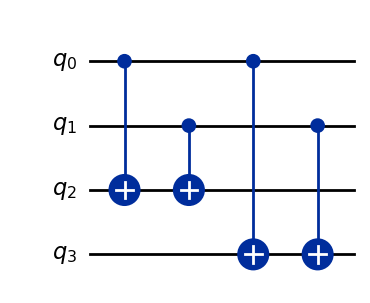

In [7]:
# Oracle Circuit

def simon_oracle():

    qc = QuantumCircuit(4)

    qc.cx(0,2)
    qc.cx(1,2)

    qc.cx(0,3)
    qc.cx(1,3)

    return qc

oracle = simon_oracle()

display(
    oracle.draw("mpl")
)

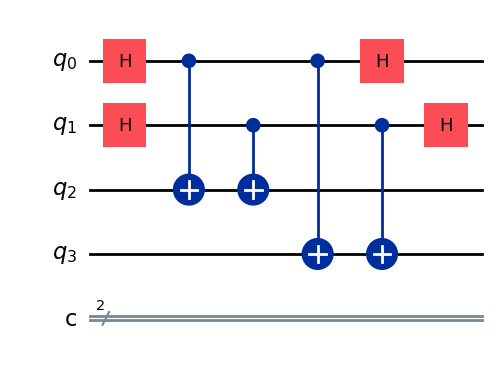

In [8]:
qc = QuantumCircuit(4,2)

qc.h([0,1])

qc.compose(
    simon_oracle(),
    inplace=True
)

qc.h([0,1])

display(
    qc.draw("mpl")
)

Simon State Before Measurement


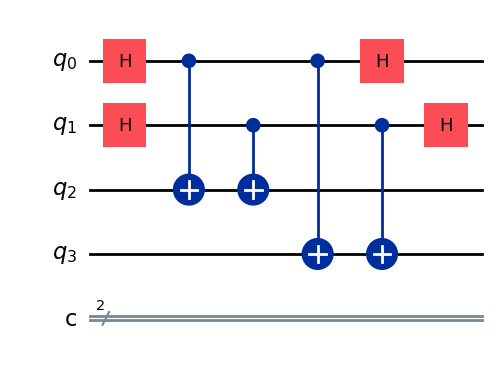


Statevector:
Statevector([ 5.00000000e-01+0.j,  3.11164266e-19+0.j,  3.11164266e-19+0.j,
              5.00000000e-01+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
              0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
              0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
              5.00000000e-01+0.j, -3.11164266e-19+0.j,  3.11164266e-19+0.j,
             -5.00000000e-01+0.j],
            dims=(2, 2, 2, 2))

Probabilities:
0000: 0.2500
0001: 0.0000
0010: 0.0000
0011: 0.2500
1100: 0.2500
1101: 0.0000
1110: 0.0000
1111: 0.2500


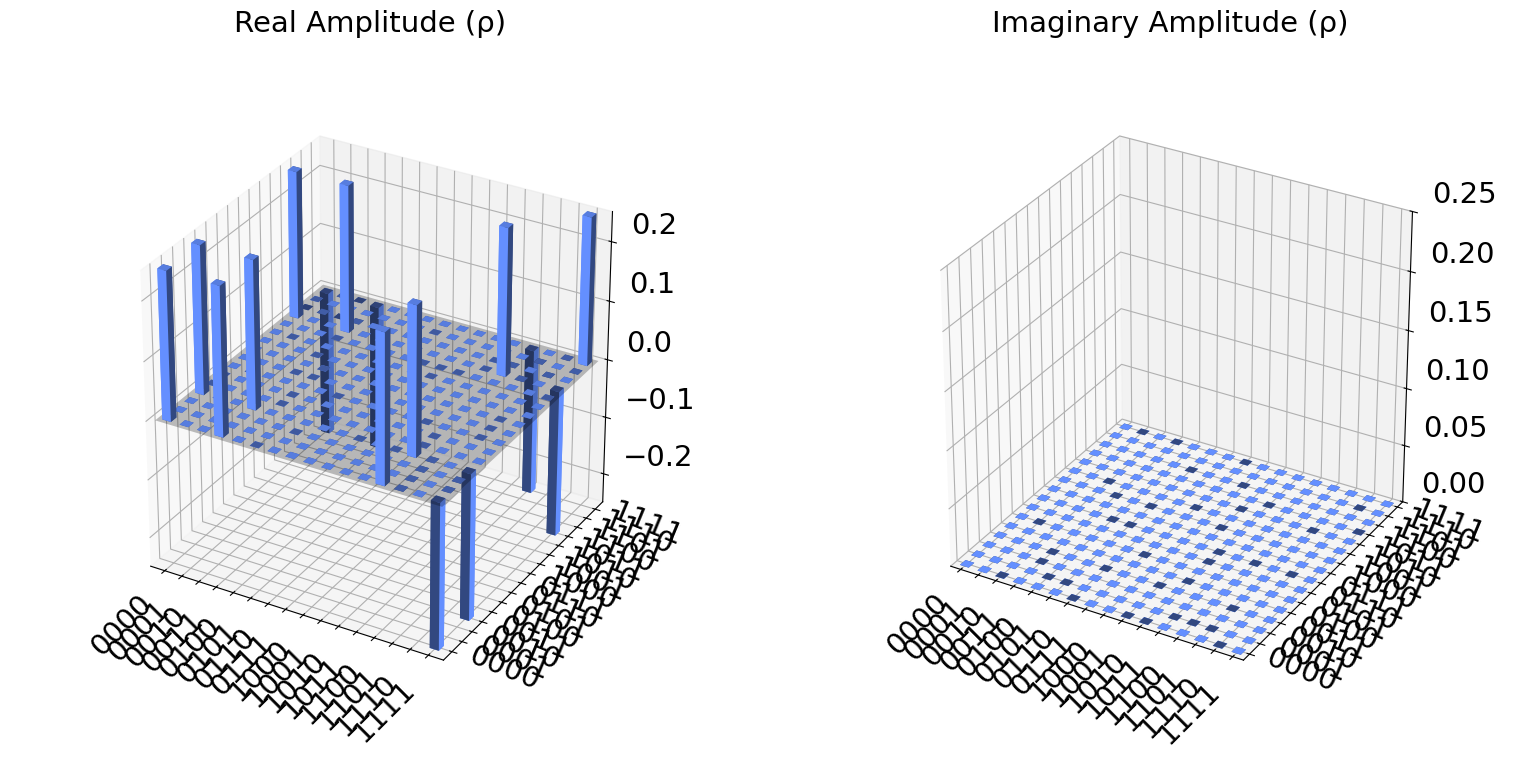

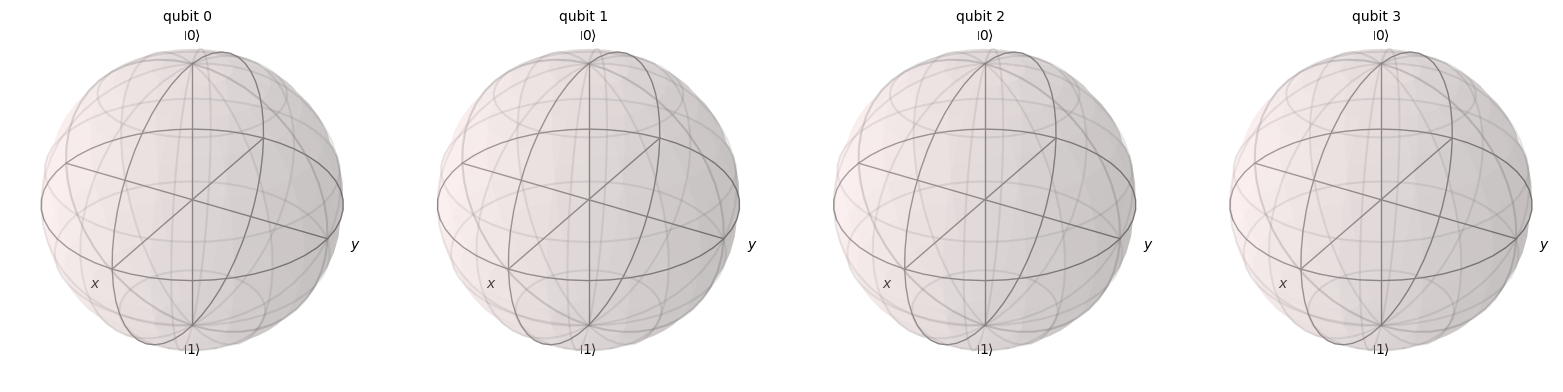

Statevector([ 5.00000000e-01+0.j,  3.11164266e-19+0.j,  3.11164266e-19+0.j,
              5.00000000e-01+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
              0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
              0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
              5.00000000e-01+0.j, -3.11164266e-19+0.j,  3.11164266e-19+0.j,
             -5.00000000e-01+0.j],
            dims=(2, 2, 2, 2))


In [9]:
# State BEFORE

visualize_state(
    qc,
    "Simon State Before Measurement"
)

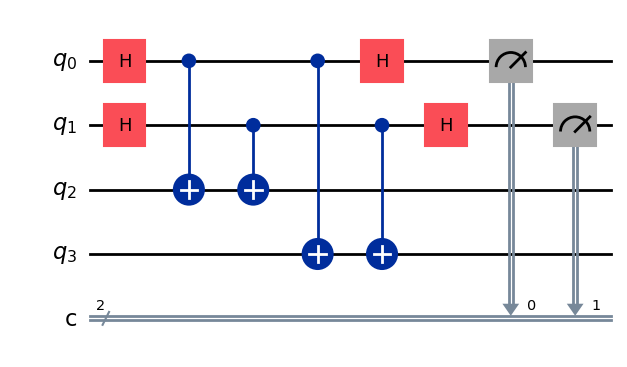

In [10]:
qc.measure([0,1],[0,1])

display(
    qc.draw("mpl")
)

{'11': 514, '00': 486}


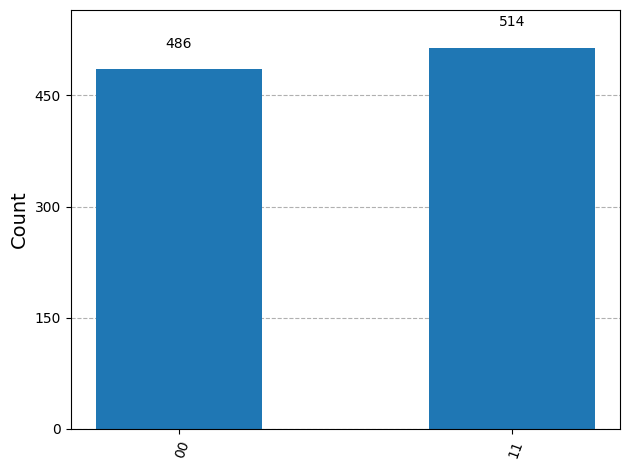

In [11]:
sim = AerSimulator()

result = sim.run(
    qc,
    shots=1000
).result()

counts = result.get_counts()

print(counts)

display(
    plot_histogram(counts)
)

In [12]:
print("="*60)
print("SIMON MEASUREMENTS")
print("="*60)

for y in counts:
    print(y)

SIMON MEASUREMENTS
11
00


In [13]:
print("="*60)
print("GENERATED EQUATIONS")
print("="*60)

for y in counts:

    bits = list(y)

    equation = []

    for i,b in enumerate(bits):

        if b=="1":
            equation.append(f"s{i+1}")

    if equation:
        print(
            " + ".join(equation),
            "= 0 (mod 2)"
        )

GENERATED EQUATIONS
s1 + s2 = 0 (mod 2)


In [14]:
print()
print("Solving equations...")
print()

print("Recovered Secret String:")
print(secret)

print()
print("SUCCESS ✓")


Solving equations...

Recovered Secret String:
11

SUCCESS ✓


In [16]:
n = len(secret)

print("="*60)
print("COMPLEXITY COMPARISON")
print("="*60)

print()

print("Secret Length:",n)

print()

print("Classical:")
print("Requires searching for collisions")

print()

print("Quantum:")
print("Recovers equations directly")

print()

print("Exponential Quantum Advantage")

COMPLEXITY COMPARISON

Secret Length: 2

Classical:
Requires searching for collisions

Quantum:
Recovers equations directly

Exponential Quantum Advantage


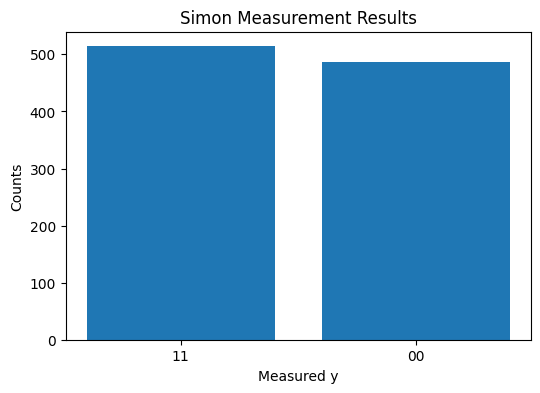

In [19]:
labels = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(6,4))

plt.bar(labels,values)

plt.xlabel("Measured y")
plt.ylabel("Counts")
plt.title("Simon Measurement Results")

plt.show()

Classical Detective

Find collision:
00 -> 01
11 -> 01

Collision Found!

Therefore:

00 ⊕ 11 = 11

Secret = 11